In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plot style
sns.set(style='whitegrid', palette='Set2')


In [23]:
import pandas as pd

# Load MachineLearningRating_v3.txt (pipe-delimited example)
df = pd.read_csv('../MachineLearningRating_v3.txt', delimiter='|', encoding='utf-8', low_memory=False)

# Show basic structure
df.shape
df.head()
df["CapitalOutstanding"] = pd.to_numeric(df["CapitalOutstanding"], errors="coerce")
df["CrossBorder"] = pd.to_numeric(df["CrossBorder"], errors="coerce")

In [12]:
print(df.columns)

Index(['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth',
       'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language',
       'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province',
       'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode',
       'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders',
       'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors',
       'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser',
       'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff',
       'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet',
       'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm',
       'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section',
       'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium',
       'TotalClaims'],
      dtype='object')


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  object 
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  object 
 5   LegalType                 1000098 non-null  object 
 6   Title                     1000098 non-null  object 
 7   Language                  1000098 non-null  object 
 8   Bank                      854137 non-null   object 
 9   AccountType               959866 non-null   object 
 10  MaritalStatus             991839 non-null   object 
 11  Gender                    990562 non-null   object 
 12  Country                   1000098 non-null  object 
 13  Province                  1

In [16]:

df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'], errors='coerce')
df['Gender'] = df['Gender'].astype('category')
df['Province'] = df['Province'].astype('category')
df['Product'] = df['Product'].astype('category')


In [17]:
df.isnull().sum().sort_values(ascending=False)


NumberOfVehiclesInFleet     1000098
CrossBorder                  999400
CustomValueEstimate          779642
Rebuilt                      641901
Converted                    641901
WrittenOff                   641901
NewVehicle                   153295
Bank                         145961
AccountType                   40232
Gender                         9536
MaritalStatus                  8259
VehicleType                     552
make                            552
mmcode                          552
Model                           552
Cylinders                       552
bodytype                        552
kilowatts                       552
NumberOfDoors                   552
VehicleIntroDate                552
cubiccapacity                   552
CapitalOutstanding                2
SubCrestaZone                     0
ItemType                          0
Province                          0
Country                           0
PostalCode                        0
MainCrestaZone              

<Axes: >

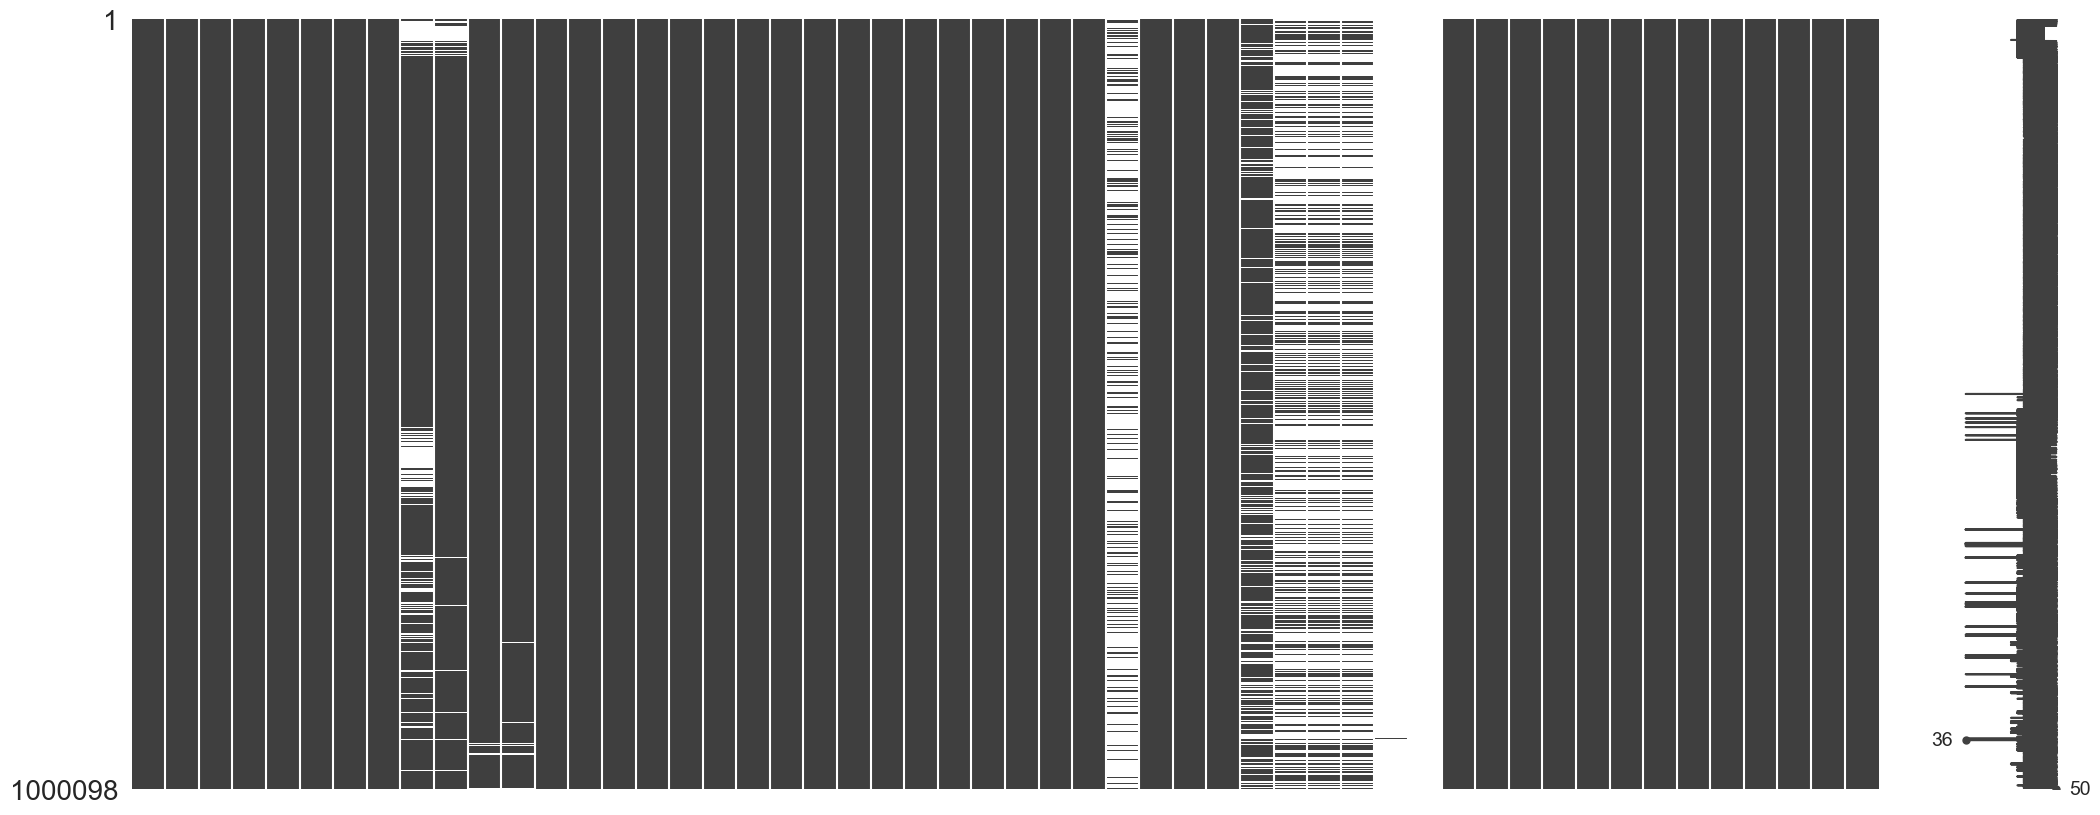

In [18]:
import missingno as msno
msno.matrix(df)


In [19]:
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']

# Summary by Province
province_summary = df.groupby('Province')[['TotalClaims', 'TotalPremium']].sum()
province_summary['LossRatio'] = province_summary['TotalClaims'] / province_summary['TotalPremium']
province_summary.sort_values('LossRatio', ascending=False)


C:\Users\PC\AppData\Local\Temp\ipykernel_17792\486445691.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  province_summary = df.groupby('Province')[['TotalClaims', 'TotalPremium']].sum()


,TotalClaims,TotalPremium,LossRatio
Province,,,
Gauteng,2.939415e+07,2.405377e+07,1.222018
KwaZulu-Natal,1.430138e+07,1.320908e+07,1.082693
Western Cape,1.038977e+07,9.806559e+06,1.059472
North West,5.920250e+06,7.490508e+06,0.790367
Mpumalanga,2.044675e+06,2.836292e+06,0.720897
Free State,3.549223e+05,5.213632e+05,0.680758
Limpopo,1.016477e+06,1.537324e+06,0.661199
Eastern Cape,1.356427e+06,2.140104e+06,0.633813
Northern Cape,8.949051e+04,3.165581e+05,0.282699


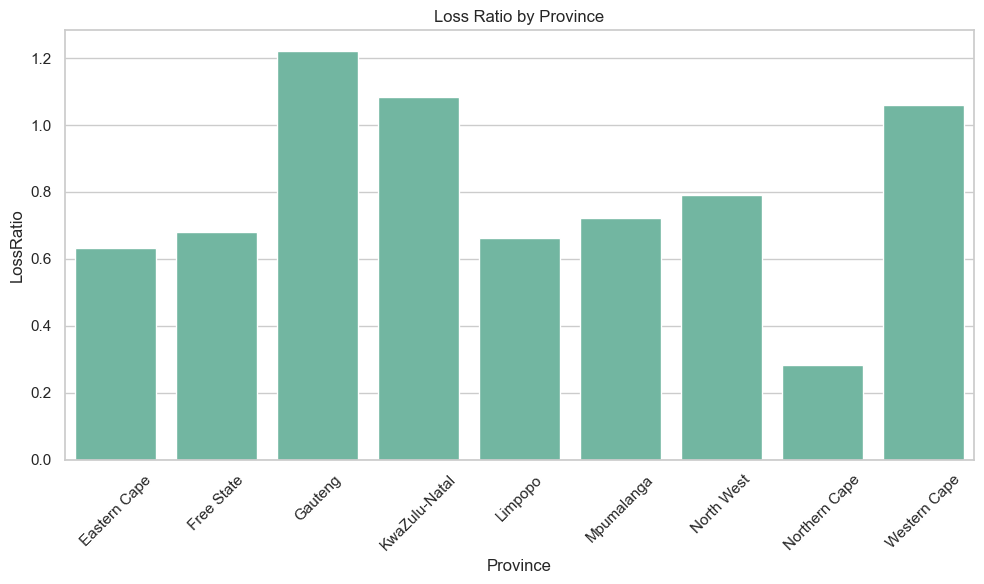

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.barplot(data=province_summary.reset_index(), x='Province', y='LossRatio')
plt.title('Loss Ratio by Province')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\PC\AppData\Local\Temp\ipykernel_17792\3842814455.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vehicle_loss_ratio = df.groupby('VehicleType')[['TotalClaims', 'TotalPremium']].sum()
C:\Users\PC\AppData\Local\Temp\ipykernel_17792\3842814455.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vehicle_loss_ratio.index, y=vehicle_loss_ratio['LossRatio'], palette='viridis')


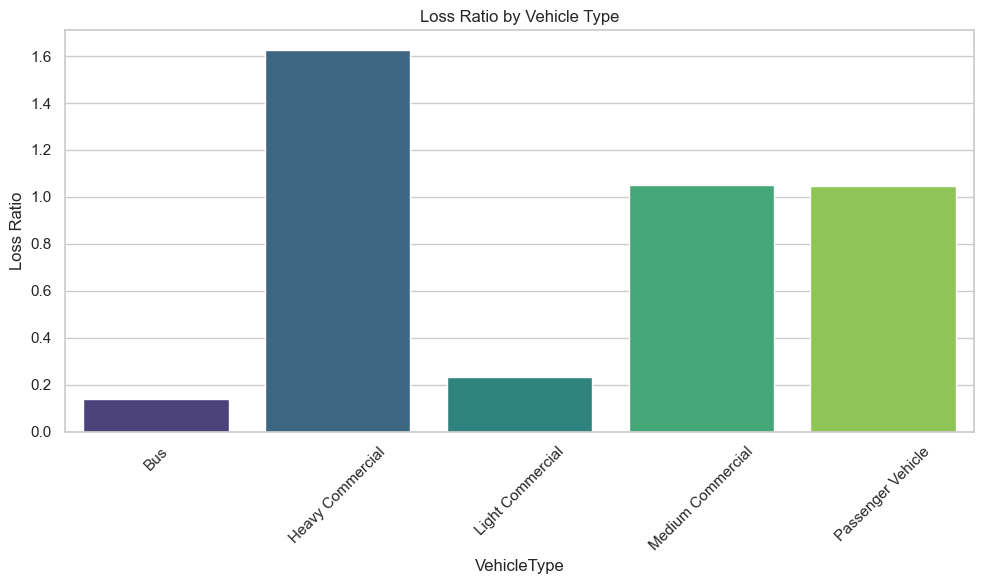

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is your main DataFrame
vehicle_loss_ratio = df.groupby('VehicleType')[['TotalClaims', 'TotalPremium']].sum()
vehicle_loss_ratio['LossRatio'] = vehicle_loss_ratio['TotalClaims'] / vehicle_loss_ratio['TotalPremium']

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=vehicle_loss_ratio.index, y=vehicle_loss_ratio['LossRatio'], palette='viridis')
plt.title('Loss Ratio by Vehicle Type')
plt.ylabel('Loss Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\PC\AppData\Local\Temp\ipykernel_17792\3591753802.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_loss_ratio = df.groupby('Gender')[['TotalClaims', 'TotalPremium']].sum()
C:\Users\PC\AppData\Local\Temp\ipykernel_17792\3591753802.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_loss_ratio.index, y=gender_loss_ratio['LossRatio'], palette='pastel')


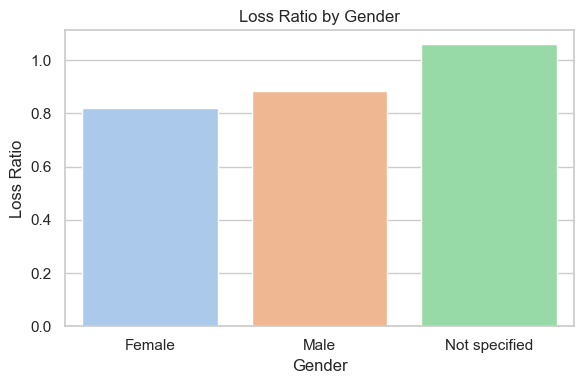

In [22]:
gender_loss_ratio = df.groupby('Gender')[['TotalClaims', 'TotalPremium']].sum()
gender_loss_ratio['LossRatio'] = gender_loss_ratio['TotalClaims'] / gender_loss_ratio['TotalPremium']

# Plot
plt.figure(figsize=(6, 4))
sns.barplot(x=gender_loss_ratio.index, y=gender_loss_ratio['LossRatio'], palette='pastel')
plt.title('Loss Ratio by Gender')
plt.ylabel('Loss Ratio')
plt.tight_layout()
plt.show()


Distribution and outliers

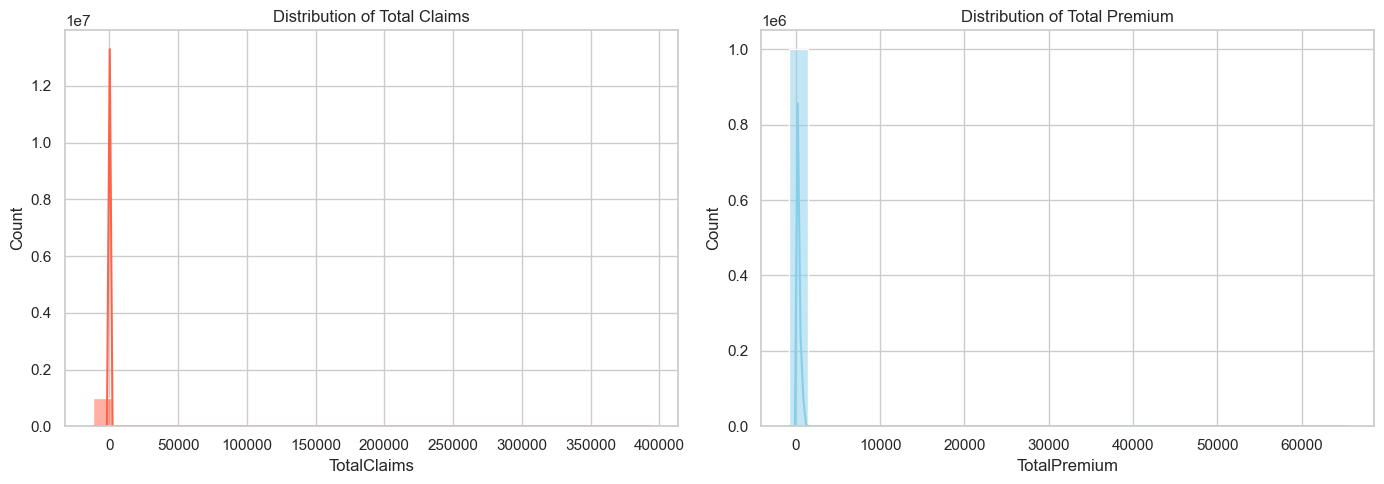

In [23]:
#Histogram of TotalClaims and TotalPremium
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['TotalClaims'], bins=30, kde=True, ax=axes[0], color='tomato')
axes[0].set_title('Distribution of Total Claims')

sns.histplot(df['TotalPremium'], bins=30, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title('Distribution of Total Premium')

plt.tight_layout()
plt.show()


Boxplot fot outlier detection

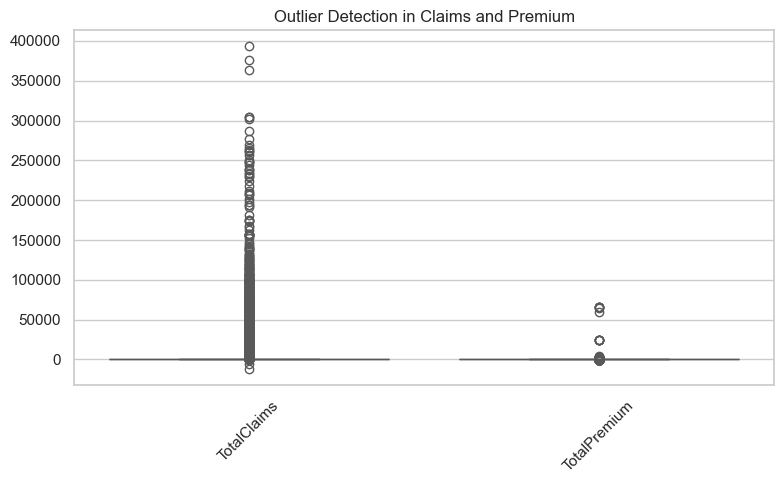

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[['TotalClaims', 'TotalPremium']])
plt.title('Outlier Detection in Claims and Premium')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


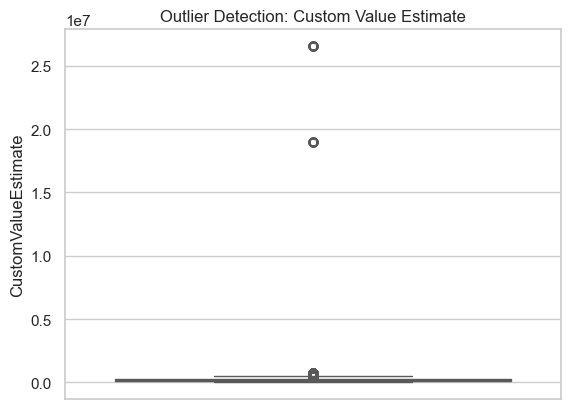

In [25]:
#customervalueestimate
sns.boxplot(y=df['CustomValueEstimate'])
plt.title('Outlier Detection: Custom Value Estimate')
plt.show()


 Temporal Trend Over 18 Months

In [26]:
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'], errors='coerce')


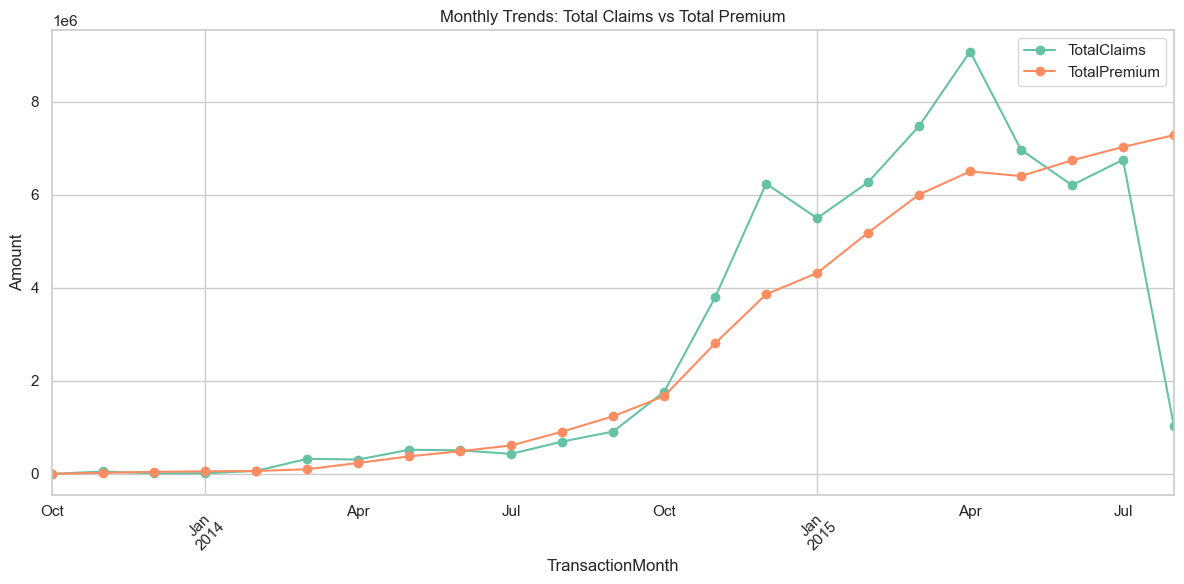

In [27]:
monthly_trend = df.groupby(df['TransactionMonth'].dt.to_period("M"))[['TotalClaims', 'TotalPremium']].sum()
monthly_trend.index = monthly_trend.index.to_timestamp()

monthly_trend.plot(figsize=(12, 6), marker='o')
plt.title('Monthly Trends: Total Claims vs Total Premium')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


Vehicle Makes/Models with Highest & Lowest Claims

In [1]:
# Top 10 makes by average claim
top_makes = df.groupby('make')['TotalClaims'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_makes.index, y=top_makes.values, palette='magma')
plt.title('Top 10 Vehicle Makes by Average Claims')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Lowest 10 (optional)
lowest_makes = df.groupby('make')['TotalClaims'].mean().sort_values().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=lowest_makes.index, y=lowest_makes.values, palette='coolwarm')
plt.title('Bottom 10 Vehicle Makes by Average Claims')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


NameError: name 'df' is not defined

In [29]:
top_models = df.groupby('Model')['TotalClaims'].mean().sort_values(ascending=False).head(10)


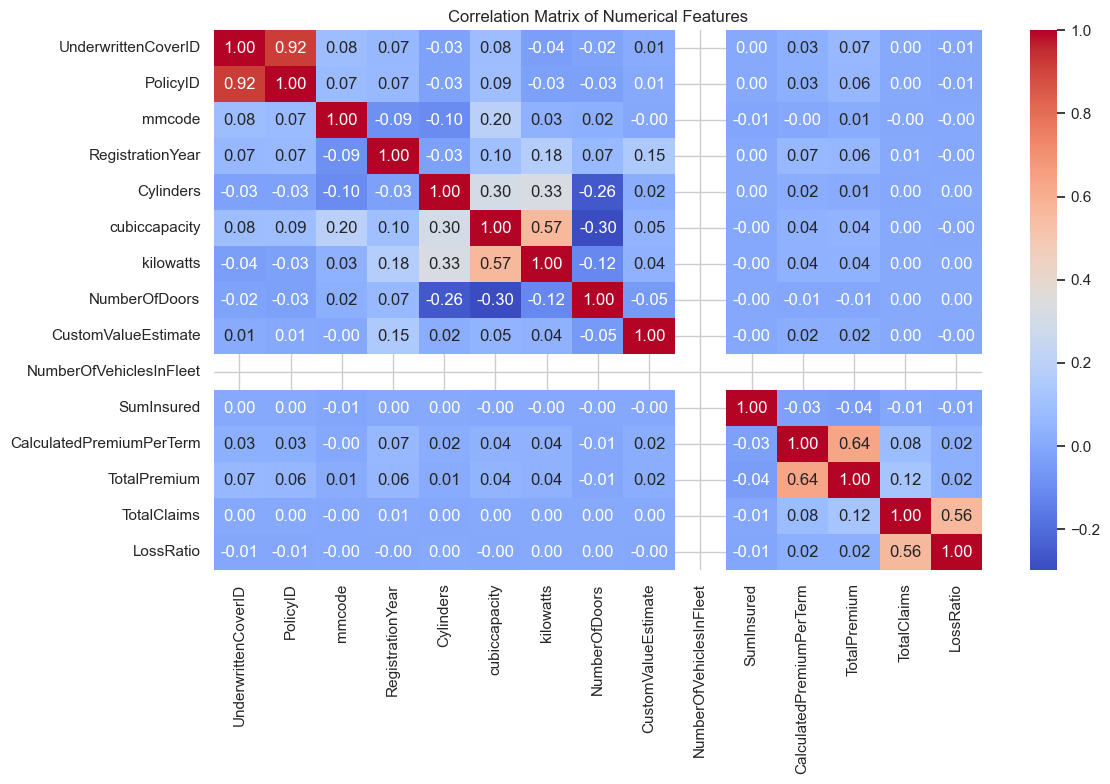

In [30]:
#Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()


C:\Users\PC\AppData\Local\Temp\ipykernel_17792\3388538650.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined = df.groupby(['Province', 'Gender'])[['TotalClaims', 'TotalPremium']].sum()


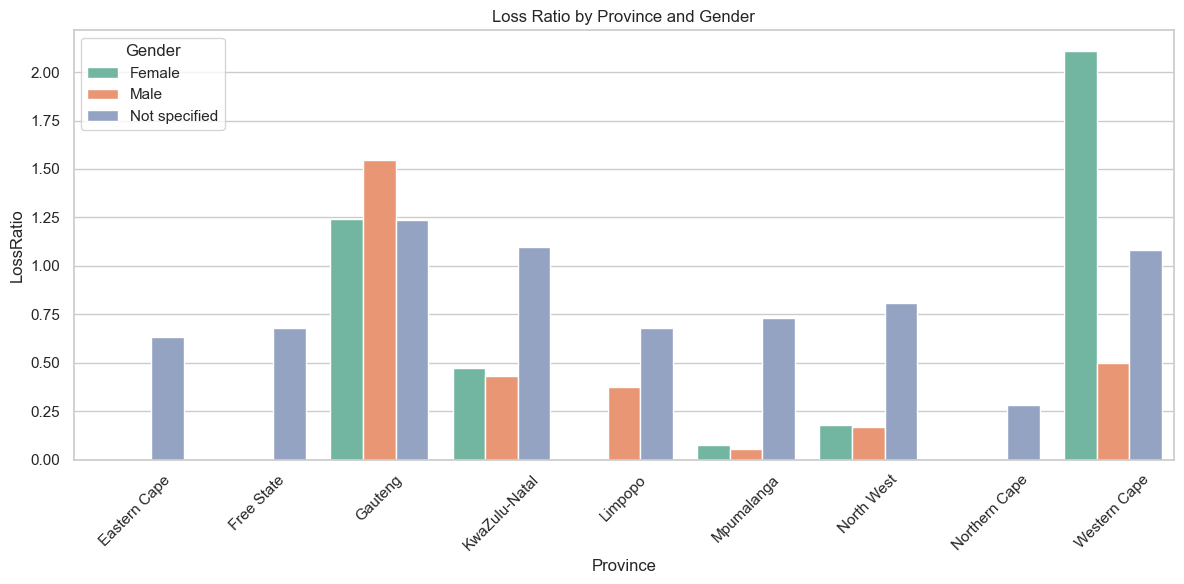

In [31]:
#Creative Insightful Plots
#loss ratio by gender and province combined
combined = df.groupby(['Province', 'Gender'])[['TotalClaims', 'TotalPremium']].sum()
combined['LossRatio'] = combined['TotalClaims'] / combined['TotalPremium']
combined = combined.reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=combined, x='Province', y='LossRatio', hue='Gender')
plt.title('Loss Ratio by Province and Gender')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


C:\Users\PC\AppData\Local\Temp\ipykernel_17792\3798284704.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_prov = df.groupby([df['TransactionMonth'].dt.to_period('M'), 'Province'])['TotalClaims'].sum().unstack().fillna(0)


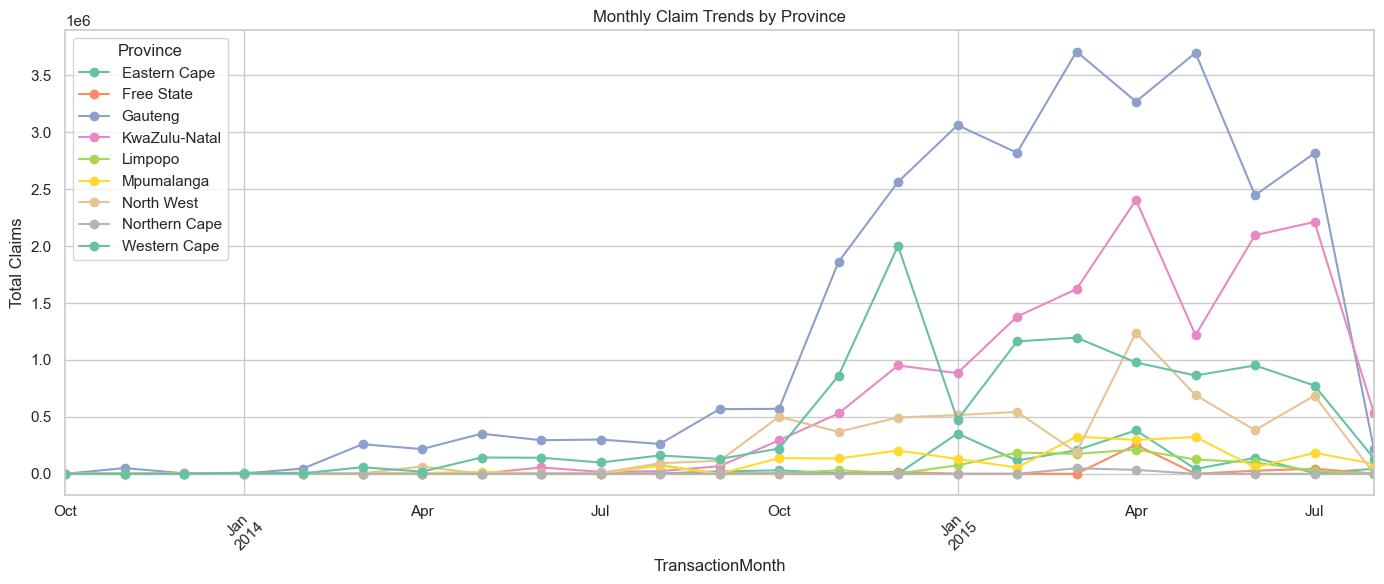

In [33]:
#average claim by number of doors
monthly_prov = df.groupby([df['TransactionMonth'].dt.to_period('M'), 'Province'])['TotalClaims'].sum().unstack().fillna(0)
monthly_prov.index = monthly_prov.index.to_timestamp()

monthly_prov.plot(figsize=(14, 6), marker='o')
plt.title('Monthly Claim Trends by Province')
plt.ylabel('Total Claims')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
